In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from pycaret import classification as pyclf


In [ ]:

path = r"C:\Users\User\Desktop\Final Year Project\Data\MasterDataset.xlsx"
df = pd.read_excel(path)

# target on 0–5 scale 
target_src = 'Final_CGPA' if 'Final_CGPA' in df.columns else ('CGPA' if 'CGPA' in df.columns else None)
if target_src is None:
    raise ValueError("No CGPA/Final_CGPA column found.")

df['CGPA_scaled'] = pd.to_numeric(df[target_src], errors='coerce')
if df['CGPA_scaled'].max() > 5.001:
    df['CGPA_scaled'] = MinMaxScaler((0,5)).fit_transform(df[['CGPA_scaled']])

# define risk levels 
bins   = [0.0, 2.0, 3.0, 3.5, 4.0, 5.0]
labels = ['High Risk','Risk','Moderate','Safe','Very Safe']
df['Risk_Level'] = pd.cut(df['CGPA_scaled'], bins=bins, labels=labels, include_lowest=True)

# select input features
gpa_cols = [c for c in df.columns if c.startswith('GPA_')]
id_col = 'REGNO' if 'REGNO' in df.columns else None

#  build modeling frame
keep = ([id_col] if id_col else []) + gpa_cols + ['Risk_Level']
clf_base = df[keep].dropna(subset=['Risk_Level']).copy()

for c in gpa_cols:
    clf_base[c] = pd.to_numeric(clf_base[c], errors='coerce')
clf_base.dropna(subset=gpa_cols, inplace=True)

print(f"Total students: {len(clf_base)}")
print("GPA features:", gpa_cols)
print("Class counts:\n", clf_base['Risk_Level'].value_counts().reindex(labels))


Total students: 1069
GPA features: ['GPA_delta', 'GPA_Y4S2', 'GPA_Y4S1', 'GPA_Y3S2', 'GPA_Y3S1', 'GPA_Y2S2', 'GPA_Y2S1', 'GPA_Y1S2', 'GPA_Y1S1']
Class counts:
 Risk_Level
High Risk     30
Risk         271
Moderate     365
Safe         295
Very Safe    108
Name: count, dtype: int64


In [4]:
clf_setup = pyclf.setup(
    data=clf_base,
    target='Risk_Level',
    train_size=0.8,
    session_id=42,
    normalize=True,
    fix_imbalance=True,
    fold=5,
    fold_shuffle=True,
    verbose=False
)

base_clf  = pyclf.compare_models(sort='F1')
tuned_clf = pyclf.tune_model(base_clf, optimize='Recall', choose_better=True)

pyclf.save_model(tuned_clf, r"C:\Users\User\Desktop\Final Year Project\Data\Best_RiskClassifier_Full")
leader = pyclf.pull()
print("Leaderboard columns:", leader.columns.tolist())
display(leader.head(10))


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
et,Extra Trees Classifier,0.9602,0.9986,0.9602,0.9616,0.9595,0.9456,0.9460,0.1580
rf,Random Forest Classifier,0.9556,0.9976,0.9556,0.9569,0.9551,0.9392,0.9397,0.1420
lightgbm,Light Gradient Boosting Machine,0.9520,0.9961,0.9520,0.9540,0.9519,0.9344,0.9350,1.1600
gbc,Gradient Boosting Classifier,0.9509,0.0000,0.9509,0.9536,0.9505,0.9328,0.9336,0.9560
dt,Decision Tree Classifier,0.9088,0.9377,0.9088,0.9131,0.9086,0.8756,0.8769,0.0300
knn,K Neighbors Classifier,0.8398,0.9675,0.8398,0.8473,0.8401,0.7830,0.7846,1.1620
lda,Linear Discriminant Analysis,0.8000,0.0000,0.8000,0.8157,0.8027,0.7305,0.7325,0.0360
lr,Logistic Regression,0.7988,0.0000,0.7988,0.8029,0.7979,0.7274,0.7290,1.5380
nb,Naive Bayes,0.5813,0.8361,0.5813,0.6475,0.5930,0.4593,0.4727,0.0280
ada,Ada Boost Classifier,0.5368,0.0000,0.5368,0.5476,0.4990,0.3696,0.3956,0.0900


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9064,0.9851,0.9064,0.9076,0.9054,0.8729,0.8736
1,0.9006,0.9821,0.9006,0.9043,0.9005,0.8651,0.8660
2,0.8830,0.9794,0.8830,0.9065,0.8874,0.8439,0.8471
3,0.9415,0.9884,0.9415,0.9429,0.9419,0.9203,0.9204
4,0.8830,0.9794,0.8830,0.8934,0.8860,0.8418,0.8429
Mean,0.9029,0.9829,0.9029,0.9109,0.9042,0.8688,0.8700
Std,0.0214,0.0035,0.0214,0.0168,0.0202,0.0284,0.0277


Fitting 5 folds for each of 10 candidates, totalling 50 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).
Transformation Pipeline and Model Successfully Saved
Leaderboard columns: ['Accuracy', 'AUC', 'Recall', 'Prec.', 'F1', 'Kappa', 'MCC']


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9064,0.9851,0.9064,0.9076,0.9054,0.8729,0.8736
1,0.9006,0.9821,0.9006,0.9043,0.9005,0.8651,0.8660
2,0.8830,0.9794,0.8830,0.9065,0.8874,0.8439,0.8471
3,0.9415,0.9884,0.9415,0.9429,0.9419,0.9203,0.9204
4,0.8830,0.9794,0.8830,0.8934,0.8860,0.8418,0.8429
Mean,0.9029,0.9829,0.9029,0.9109,0.9042,0.8688,0.8700
Std,0.0214,0.0035,0.0214,0.0168,0.0202,0.0284,0.0277


=== TRAIN ===
              precision    recall  f1-score   support

   High Risk       1.00      1.00      1.00        24
    Moderate       1.00      1.00      1.00       292
        Risk       1.00      1.00      1.00       217
        Safe       1.00      1.00      1.00       236
   Very Safe       1.00      1.00      1.00        86

    accuracy                           1.00       855
   macro avg       1.00      1.00      1.00       855
weighted avg       1.00      1.00      1.00       855

=== TEST ===
              precision    recall  f1-score   support

   High Risk       0.86      1.00      0.92         6
    Moderate       0.97      0.89      0.93        73
        Risk       0.96      0.94      0.95        54
        Safe       0.91      1.00      0.95        59
   Very Safe       1.00      1.00      1.00        22

    accuracy                           0.95       214
   macro avg       0.94      0.97      0.95       214
weighted avg       0.95      0.95      0.95       

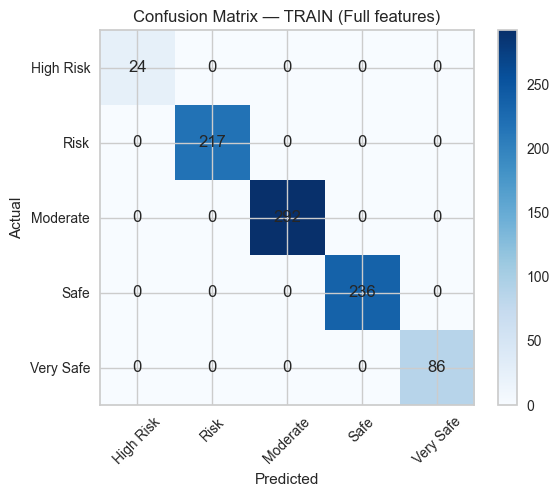

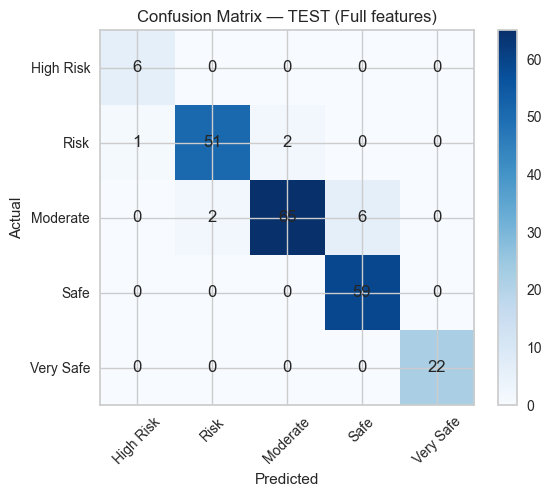

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

X_train = pyclf.get_config('X_train')
y_train = pyclf.get_config('y_train')
X_test  = pyclf.get_config('X_test')
y_test  = pyclf.get_config('y_test')

train_pred = pyclf.predict_model(tuned_clf, data=X_train)
test_pred  = pyclf.predict_model(tuned_clf, data=X_test)

pred_col = next((c for c in ['prediction_label','Label','prediction'] if c in test_pred.columns), None)

print("TRAIN")
print(classification_report(y_train, train_pred[pred_col]))
print("TEST ")
print(classification_report(y_test, test_pred[pred_col]))

def plot_cm(cm, title):
    plt.figure(figsize=(6,5))
    plt.imshow(cm, cmap='Blues')
    plt.title(title)
    plt.xticks(range(len(labels)), labels, rotation=45)
    plt.yticks(range(len(labels)), labels)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i,j], ha='center', va='center')
    plt.ylabel('Actual'); plt.xlabel('Predicted'); plt.colorbar(); plt.tight_layout(); plt.show()

cm_train = confusion_matrix(y_train, train_pred[pred_col], labels=labels)
cm_test  = confusion_matrix(y_test,  test_pred[pred_col],  labels=labels)
plot_cm(cm_train,"Confusion Matrix — TRAIN (Full features)")
plot_cm(cm_test,"Confusion Matrix — TEST (Full features)")


In [13]:
# masking Y3–Y4 features as NaN
early_test = X_test.copy()
mask_cols = [c for c in early_test.columns if any(k in c for k in ['Y3','Y4'])]
early_test[mask_cols] = np.nan


forecast_pred = pyclf.predict_model(tuned_clf, data=early_test)
print("Forecast using only Y1–Y2 features test")
print(classification_report(y_test, forecast_pred[pred_col]))

cm_forecast = confusion_matrix(y_test, forecast_pred[pred_col], labels=labels)
plot_cm(cm_forecast,"Confusion Matrix — Forecast (Y1–Y2 only)")


NameError: name 'X_test' is not defined

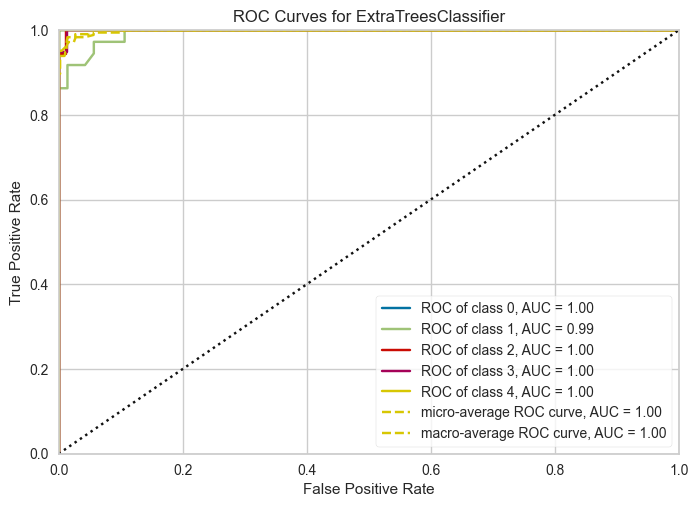

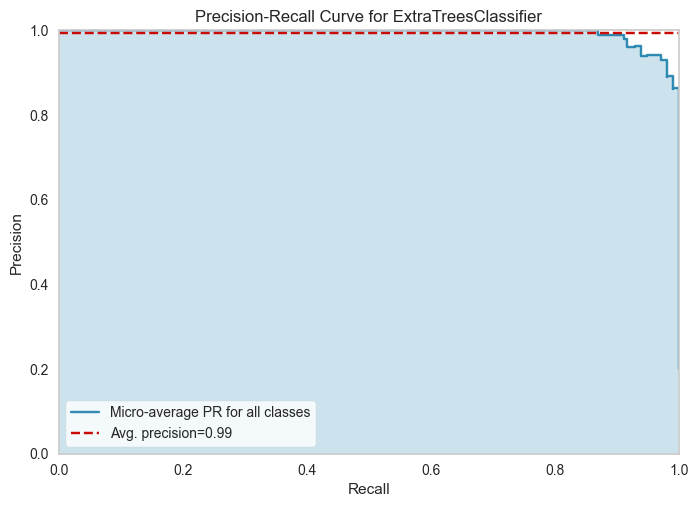

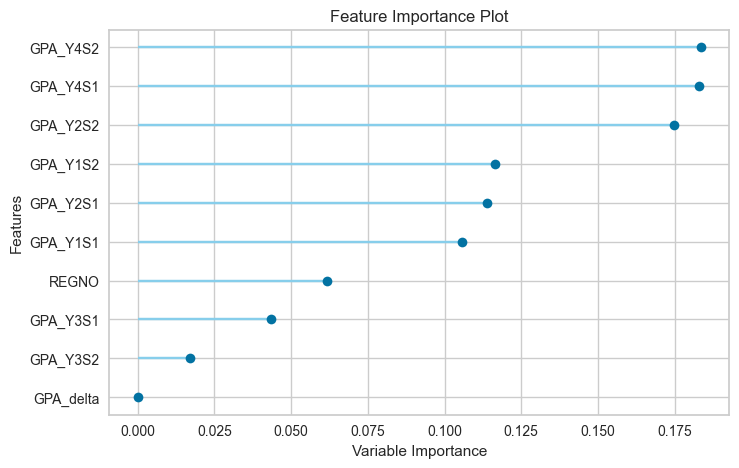

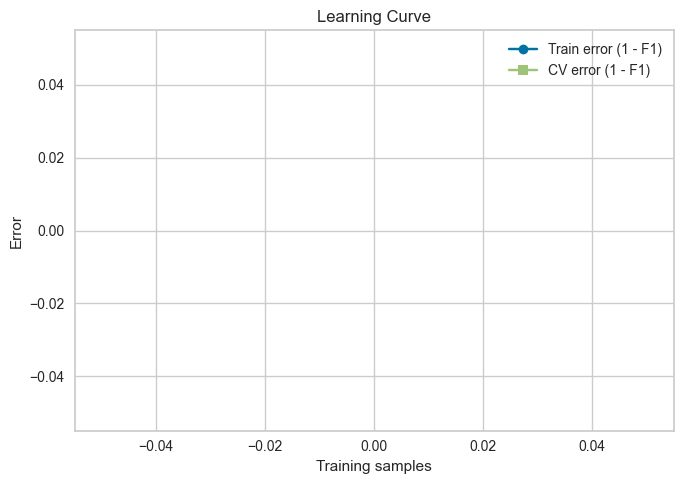

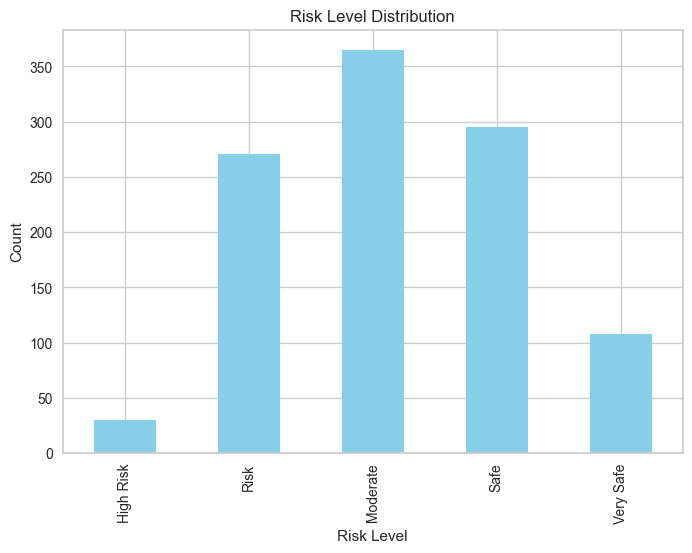

In [7]:
# ROC / PR curves
pyclf.plot_model(tuned_clf, plot='auc')
pyclf.plot_model(tuned_clf, plot='pr')

# Feature importance
pyclf.plot_model(tuned_clf, plot='feature')

# Learning curve (1-F1 error vs training size)
from sklearn.model_selection import learning_curve
from sklearn.metrics import f1_score, make_scorer

estimator = tuned_clf
scorer = make_scorer(f1_score, average='macro')
sizes, train_scores, val_scores = learning_curve(estimator, X_train, y_train, cv=5,
                                                 train_sizes=np.linspace(0.1,1.0,8),
                                                 scoring=scorer, shuffle=True, random_state=42)
train_err = 1 - train_scores.mean(axis=1)
val_err   = 1 - val_scores.mean(axis=1)
plt.figure(figsize=(7,5))
plt.plot(sizes, train_err, marker='o', label='Train error (1 - F1)')
plt.plot(sizes, val_err, marker='s', label='CV error (1 - F1)')
plt.xlabel('Training samples'); plt.ylabel('Error'); plt.title('Learning Curve')
plt.legend(); plt.tight_layout(); plt.show()

# Histogram of risk level imbalance
clf_base['Risk_Level'].value_counts().reindex(labels).plot(kind='bar', color='skyblue')
plt.title('Risk Level Distribution'); plt.xlabel('Risk Level'); plt.ylabel('Count'); plt.show()


In [ ]:

early_cols = [c for c in clf_base.columns if c.startswith(('GPA_Y1S1','GPA_Y1S2','GPA_Y2S1','GPA_Y2S2'))]
use_cols = early_cols + ['Risk_Level']
clf_early = clf_base[use_cols].dropna().copy()

from pycaret import classification as pyclf

pyclf.setup(
    data=clf_early,
    target='Risk_Level',
    train_size=0.8,
    session_id=42,
    normalize=True,
    fix_imbalance=True,
    fold=5, fold_shuffle=True,
    verbose=False
)

early_base  = pyclf.compare_models(sort='F1')
early_tuned = pyclf.tune_model(early_base, optimize='Recall', choose_better=True)

# Evaluate early-only model on its own test split
early_pred_test = pyclf.predict_model(early_tuned)
print(pyclf.pull().head(10))


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
et,Extra Trees Classifier,0.9041,0.9892,0.9041,0.9080,0.9036,0.8695,0.8704,0.1280
lightgbm,Light Gradient Boosting Machine,0.8947,0.9718,0.8947,0.8986,0.8947,0.8567,0.8576,0.7580
rf,Random Forest Classifier,0.8947,0.9770,0.8947,0.8990,0.8941,0.8565,0.8576,0.1560
dt,Decision Tree Classifier,0.8690,0.9095,0.8690,0.8734,0.8686,0.8215,0.8228,0.0360
gbc,Gradient Boosting Classifier,0.8667,0.0000,0.8667,0.8707,0.8666,0.8184,0.8197,0.5260
knn,K Neighbors Classifier,0.7205,0.9040,0.7205,0.7320,0.7210,0.6233,0.6251,0.0360
qda,Quadratic Discriminant Analysis,0.6456,0.0000,0.6456,0.6674,0.6497,0.5267,0.5295,0.0260
lr,Logistic Regression,0.6444,0.0000,0.6444,0.6724,0.6494,0.5274,0.5315,0.0280
nb,Naive Bayes,0.6398,0.8755,0.6398,0.6685,0.6455,0.5206,0.5243,0.0280
lda,Linear Discriminant Analysis,0.6386,0.0000,0.6386,0.6631,0.6421,0.5201,0.5238,0.0260


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7251,0.9266,0.7251,0.7482,0.7311,0.6269,0.6290
1,0.7076,0.9286,0.7076,0.7347,0.7143,0.6113,0.6141
2,0.7778,0.9492,0.7778,0.8185,0.7896,0.7050,0.7090
3,0.7251,0.9208,0.7251,0.7328,0.7250,0.6287,0.6300
4,0.6901,0.9084,0.6901,0.7308,0.7006,0.5902,0.5948
Mean,0.7251,0.9267,0.7251,0.7530,0.7321,0.6324,0.6354
Std,0.0294,0.0133,0.0294,0.0333,0.0305,0.0388,0.0390


Fitting 5 folds for each of 10 candidates, totalling 50 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Extra Trees Classifier,0.9252,0.9931,0.9252,0.9263,0.9250,0.8979,0.8984


                    Model  Accuracy     AUC  Recall   Prec.     F1   Kappa  \
0  Extra Trees Classifier    0.9252  0.9931  0.9252  0.9263  0.925  0.8979   

      MCC  
0  0.8984  


In [ ]:
e = clf_early.copy()
e['Y1_avg'] = e[['GPA_Y1S1','GPA_Y1S2']].mean(axis=1)
e['Y2_avg'] = e[['GPA_Y2S1','GPA_Y2S2']].mean(axis=1)
e['trend_Y1Y2'] = e['Y2_avg'] - e['Y1_avg']           # student improve or not
e['min_Y1Y2'] = e[['GPA_Y1S1','GPA_Y1S2','GPA_Y2S1','GPA_Y2S2']].min(axis=1)
e['max_Y1Y2'] = e[['GPA_Y1S1','GPA_Y1S2','GPA_Y2S1','GPA_Y2S2']].max(axis=1)


In [ ]:
from sklearn.metrics import recall_score, make_scorer

#  give extra weight to the first two classes
def recall_at_risk(y_true, y_pred):
    labels_order = ['High Risk','Risk','Moderate','Safe','Very Safe']
    # per-class recall
    rec = recall_score(y_true, y_pred, labels=labels_order, average=None, zero_division=0)
    #why did I pick these weights?
    weights = np.array([0.4, 0.3, 0.15, 0.10, 0.05])
    return float((rec * weights).sum())

pyclf.add_metric('riskrecall', 'Risk-Weighted Recall', recall_at_risk, greater_is_better=True)

early_tuned = pyclf.tune_model(early_base, optimize='riskrecall', choose_better=True)


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,Risk-Weighted Recall
Fold,,,,,,,,
0,0.3801,0.8672,0.3801,0.4929,0.3704,0.2462,0.2722,0.0000
1,0.4035,0.8506,0.4035,0.5300,0.4100,0.2731,0.2973,0.0000
2,0.4094,0.8644,0.4094,0.5649,0.4188,0.2857,0.3142,0.0000
3,0.4269,0.8639,0.4269,0.6069,0.4452,0.3071,0.3376,0.0000
4,0.4035,0.8478,0.4035,0.6066,0.4199,0.2848,0.3192,0.0000
Mean,0.4047,0.8587,0.4047,0.5603,0.4129,0.2794,0.3081,0.0000
Std,0.0150,0.0080,0.0150,0.0443,0.0243,0.0199,0.0221,0.0000


Fitting 5 folds for each of 10 candidates, totalling 50 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


In [ ]:
from sklearn.metrics import accuracy_score, f1_score

# full-feature test results 
acc_full = 0.9602  
f1_full  = 0.9595  

# early-only test predictions
Xte_e = pyclf.get_config('X_test'); yte_e = pyclf.get_config('y_test')
pred_e = pyclf.predict_model(early_tuned, data=Xte_e)
pcol   = next(c for c in ['prediction_label','Label','prediction'] if c in pred_e.columns)

acc_early = accuracy_score(yte_e, pred_e[pcol])
f1_early  = f1_score(yte_e, pred_e[pcol], average='macro')

print(f"Full features:  Acc={acc_full:.3f}, F1={f1_full:.3f}")
print(f"Early only:     Acc={acc_early:.3f}, F1={f1_early:.3f}")


Full features:  Acc=0.960, F1=0.960
Early only:     Acc=0.925, F1=0.933


In [ ]:
from sklearn.metrics import classification_report, recall_score, precision_score, f1_score, confusion_matrix
import numpy as np
import pandas as pd

X_test  = pyclf.get_config('X_test')
y_test  = pyclf.get_config('y_test')
pred_e  = pyclf.predict_model(early_tuned, data=pyclf.get_config('X_test'))
pred_col = next(c for c in ['prediction_label','Label','prediction','Predicted'] if c in pred_e.columns)

labels_order = ['High Risk','Risk','Moderate','Safe','Very Safe']
print(classification_report(y_test, pred_e[pred_col], labels=labels_order, digits=4))

# give weight to lower gpa
w = np.array([0.4, 0.3, 0.15, 0.10, 0.05])  
rec = recall_score(y_test, pred_e[pred_col], labels=labels_order, average=None, zero_division=0)
risk_weighted_recall = float((rec * w).sum())

print(f"Risk-weighted Recall (early-only): {risk_weighted_recall:.3f}")


              precision    recall  f1-score   support

   High Risk     1.0000    0.8333    0.9091         6
        Risk     0.9434    0.9259    0.9346        54
    Moderate     0.9143    0.8767    0.8951        73
        Safe     0.8906    0.9661    0.9268        59
   Very Safe     1.0000    1.0000    1.0000        22

    accuracy                         0.9252       214
   macro avg     0.9497    0.9204    0.9331       214
weighted avg     0.9263    0.9252    0.9250       214

Risk-weighted Recall (early-only): 0.889


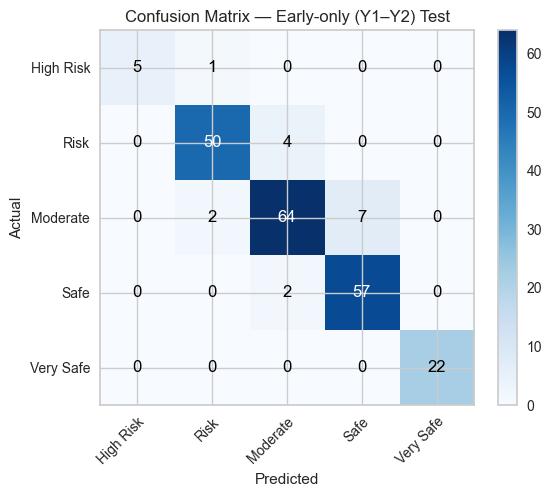

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

labels_order = ['High Risk','Risk','Moderate','Safe','Very Safe']


cm = confusion_matrix(y_test, pred_e[pred_col], labels=labels_order)

fig, ax = plt.subplots(figsize=(6,5))
im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
ax.figure.colorbar(im, ax=ax)


ax.set(
    xticks=np.arange(len(labels_order)),
    yticks=np.arange(len(labels_order)),
    xticklabels=labels_order,
    yticklabels=labels_order,
    title="Confusion Matrix — Early-only (Y1–Y2) Test",
    ylabel="Actual",
    xlabel="Predicted"
)


plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")


thresh = cm.max() / 2
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, format(cm[i, j], 'd'),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black")

plt.tight_layout()
plt.show()


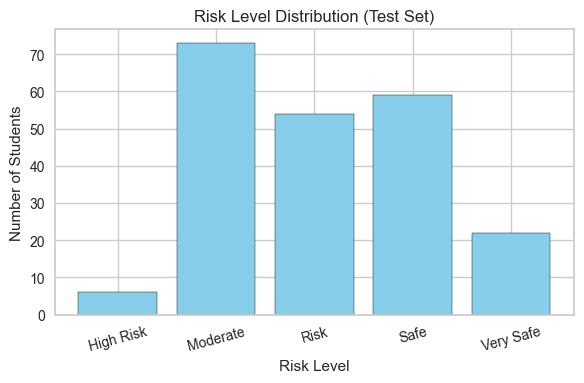

In [ ]:
# Risk level distribution 
plt.figure(figsize=(6,4))
unique, counts = np.unique(y_test, return_counts=True)
plt.bar(unique, counts, color='skyblue', edgecolor='black')
plt.title("Risk Level Distribution (Test Set)")
plt.xlabel("Risk Level")
plt.ylabel("Number of Students")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


In [15]:
pyclf.save_model(early_tuned, r"C:\Users\User\Desktop\Final Year Project\Data\Best_RiskClassifier_EarlyWeighted")


Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('label_encoding',
                  TransformerWrapperWithInverse(exclude=None, include=None,
                                                transformer=LabelEncoder())),
                 ('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['GPA_Y2S2', 'GPA_Y2S1', 'GPA_Y1S2',
                                              'GPA_Y1S1'],
                                     transformer=SimpleImputer(add_indicator=False,
                                                               copy=True,
                                                               fill_value=None,
                                                               keep_empty_features=Fal...
                  ExtraTreesClassifier(bootstrap=False, ccp_alpha=0.0,
                                       class_weight=None, criterion='gini',
                                       max_depth=None, max_featu

In [2]:
!pip install seaborn


  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)



[notice] A new release of pip is available: 24.2 -> 25.3
[notice] To update, run: C:\Users\User\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


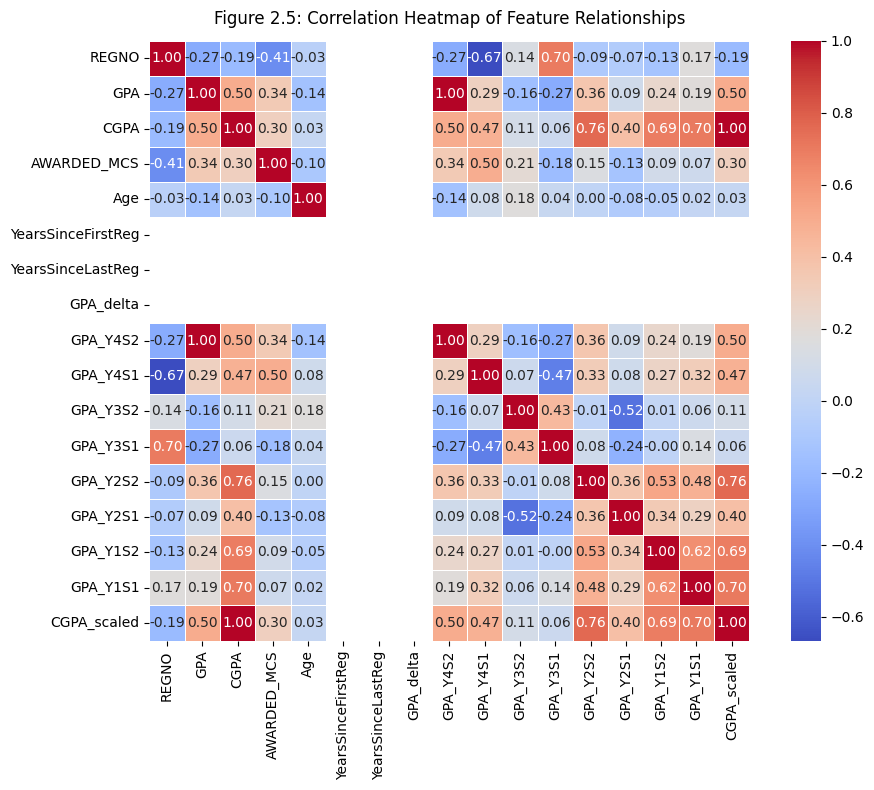

In [5]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load your master dataset using full path
df = pd.read_excel(r"C:\Users\User\Desktop\Final Year Project\Data\MasterDataset.xlsx")

# Select only numeric columns automatically
numeric_df = df.select_dtypes(include=['number'])

# Compute correlation matrix
corr_matrix = numeric_df.corr()

# Plot correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    square=True,
    linewidths=0.5
)

# Title and layout
plt.title("Figure 2.5: Correlation Heatmap of Feature Relationships", fontsize=12, pad=12)
plt.tight_layout()
plt.show()


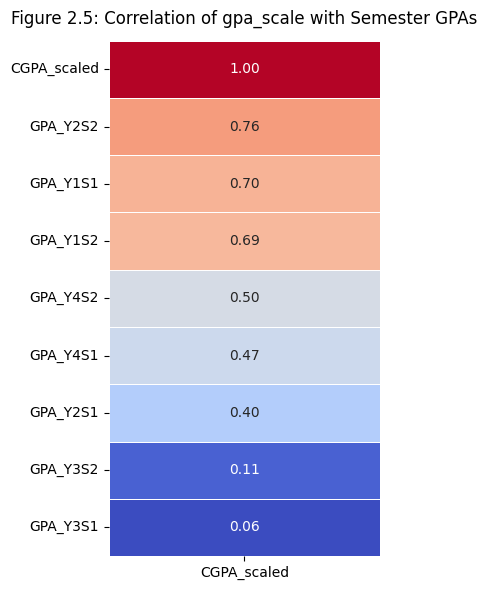

In [8]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_excel(r"C:\Users\User\Desktop\Final Year Project\Data\MasterDataset.xlsx")

# List of semester GPA columns (edit if your column names differ slightly)
semester_cols = ['GPA_Y1S1', 'GPA_Y1S2', 'GPA_Y2S1', 'GPA_Y2S2',
                 'GPA_Y3S1', 'GPA_Y3S2', 'GPA_Y4S1', 'GPA_Y4S2']

# Select only the relevant columns
corr_df = df[['CGPA_scaled'] + semester_cols]

# Compute correlation matrix
corr_matrix = corr_df.corr()[['CGPA_scaled']].sort_values(by='CGPA_scaled', ascending=False)

# Plot heatmap
plt.figure(figsize=(4, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    cbar=False,
    linewidths=0.5
)

# Title and layout
plt.title("Figure 2.5: Correlation of gpa_scale with Semester GPAs", fontsize=12, pad=12)
plt.tight_layout()
plt.show()


C:\Users\User\AppData\Local\Temp\ipykernel_10692\3933980114.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Metric', y='Mean', data=df_perf, palette='Blues_d')


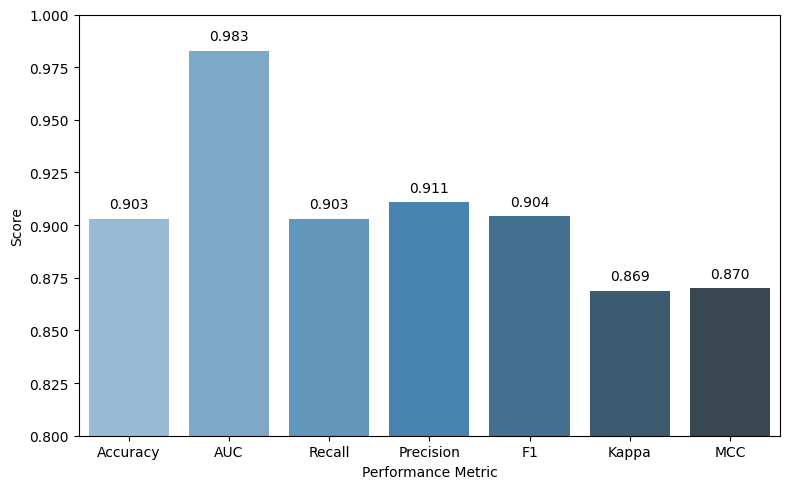

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Mean performance values from your table
data = {
    'Metric': ['Accuracy', 'AUC', 'Recall', 'Precision', 'F1', 'Kappa', 'MCC'],
    'Mean': [0.9029, 0.9829, 0.9029, 0.9109, 0.9042, 0.8688, 0.8700]
}

# Convert to DataFrame
df_perf = pd.DataFrame(data)

# Plot bar chart
plt.figure(figsize=(8, 5))
sns.barplot(x='Metric', y='Mean', data=df_perf, palette='Blues_d')

# Add values on top of bars
for i, v in enumerate(df_perf['Mean']):
    plt.text(i, v + 0.005, f"{v:.3f}", ha='center', fontsize=10)

# Chart details

plt.ylim(0.8, 1.0)
plt.ylabel("Score")
plt.xlabel("Performance Metric")
plt.tight_layout()
plt.show()


In [8]:
from pycaret.classification import load_model, predict_model, pull
import pandas as pd

# Load the improved model
model = load_model(r"C:\Users\User\Desktop\Final Year Project\Data\Best_RiskClassifier_EarlyWeighted")

# Load your dataset
data = pd.read_excel(r"C:\Users\User\Desktop\Final Year Project\Data\MasterDataset.xlsx")

# Run predictions
predictions = predict_model(model, data=data)

# Pull the latest results table from PyCaret
results = pull()

# Display metrics summary
print("\n📊 Improved Model Performance Summary (Best_RiskClassifier_EarlyWeighted)")
print(results)


Transformation Pipeline and Model Successfully Loaded


ValueError: _CURRENT_EXPERIMENT global variable is not set. Please run setup() first.

In [12]:
# === Load & predict ===
from pycaret.classification import load_model, predict_model
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

MODEL_PATH = r"C:\Users\User\Desktop\Final Year Project\Data\Best_RiskClassifier_EarlyWeighted"
DATA_PATH  = r"C:\Users\User\Desktop\Final Year Project\Data\MasterDataset.xlsx"

model = load_model(MODEL_PATH)
data = pd.read_excel(DATA_PATH)

predictions = predict_model(model, data=data)  # adds 'prediction_label' (+ 'prediction_score' if available)

# === Find the true target column name ===
# Common candidates—add yours if needed:
CANDIDATES = [
    'risk_level','Risk_Level','risk','class','Class','target','Target',
    'performance_category','Performance_Category','cgpa_category','CGPA_Category',
    'gpa_scale','GPA_Scale','label','Label'
]

target_name = None
for col in CANDIDATES:
    if col in predictions.columns:
        target_name = col
        break
# If not present in predictions, try original data columns:
if target_name is None:
    for col in CANDIDATES:
        if col in data.columns:
            target_name = col
            break

if target_name is None:
    print("❗ Could not auto-detect the target column.")
    print("Columns in predictions:", list(predictions.columns))
    print("Columns in original data:", list(data.columns))
    print("➡️ Set target_name manually to your true label column, e.g.: target_name = 'risk_level'")
else:
    # === Compute metrics ===
    y_true = predictions[target_name]
    y_pred = predictions['prediction_label']

    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_true, y_pred, average='weighted',  zero_division=0)
    f1   = f1_score(y_true, y_pred, average='weighted',       zero_division=0)

    print("\n📊 Improved Model Performance Summary (Best_RiskClassifier_EarlyWeighted)")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")

    # Optional: detailed per-class report
    print("\nPer-class report:")
    print(classification_report(y_true, y_pred, zero_division=0))

    # Optional: confusion matrix (matplotlib-only, no seaborn)
    import matplotlib.pyplot as plt
    import numpy as np

    labels = sorted(pd.unique(pd.concat([y_true, y_pred], ignore_index=True)))
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    plt.figure(figsize=(6, 5))
    plt.imshow(cm, interpolation='nearest')
    plt.title("Confusion Matrix – Improved Model")
    plt.xticks(ticks=np.arange(len(labels)), labels=labels, rotation=45, ha='right')
    plt.yticks(ticks=np.arange(len(labels)), labels=labels)
    plt.xlabel("Predicted")
    plt.ylabel("True")

    # add counts on cells
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], ha="center", va="center")

    plt.tight_layout()
    plt.show()


Transformation Pipeline and Model Successfully Loaded
❗ Could not auto-detect the target column.
Columns in predictions: ['REGNO', 'GPA', 'CGPA', 'AWARDED_MCS', 'Faculty_x', 'DegreeType', 'Gender', 'Funding', 'YearJoined', 'Age', 'YearsSinceFirstReg', 'YearsSinceLastReg', 'FIRST_CHOISE_NAME', 'SECOND_CHOISE_NAME', 'PROCESS_CHOISE_NAME', 'SUBJECT', 'GRADE', 'Faculty_y', 'Degree', 'Status', 'GPA_delta', 'GPA_Y4S2', 'GPA_Y4S1', 'GPA_Y3S2', 'GPA_Y3S1', 'GPA_Y2S2', 'GPA_Y2S1', 'GPA_Y1S2', 'GPA_Y1S1', 'CGPA_scaled', 'prediction_label', 'prediction_score']
Columns in original data: ['REGNO', 'GPA', 'CGPA', 'AWARDED_MCS', 'Faculty_x', 'DegreeType', 'Gender', 'Funding', 'YearJoined', 'Age', 'YearsSinceFirstReg', 'YearsSinceLastReg', 'FIRST_CHOISE_NAME', 'SECOND_CHOISE_NAME', 'PROCESS_CHOISE_NAME', 'SUBJECT', 'GRADE', 'Faculty_y', 'Degree', 'Status', 'GPA_delta', 'GPA_Y4S2', 'GPA_Y4S1', 'GPA_Y3S2', 'GPA_Y3S1', 'GPA_Y2S2', 'GPA_Y2S1', 'GPA_Y1S2', 'GPA_Y1S1', 'CGPA_scaled']
➡️ Set target_name manu

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Example data (replace with your actual scores)
# Before = model using original features
# After = model after adding weights and new features
data = {
    'Metric': ['Accuracy', 'F1-score'],
    'Before Improvement': [0.9252, 0.9250],
    'After Improvement': [0.91, 0.9155]  # example — update with your new results
}

# Convert to DataFrame
df_compare = pd.DataFrame(data)

# Reshape the data for Seaborn
df_melted = df_compare.melt(id_vars='Metric', var_name='Model Version', value_name='Score')

# Plot grouped bar chart
plt.figure(figsize=(7, 5))
sns.barplot(x='Metric', y='Score', hue='Model Version', data=df_melted, palette='coolwarm')

# Add labels on top of bars
for container in plt.gca().containers:
    plt.bar_label(container, fmt='%.3f', padding=3)

# Chart details
plt.title("Figure 2.14: Comparison of Model Performance Before vs After Improvement", fontsize=12, pad=12)
plt.ylim(0.85, 1.0)
plt.ylabel("Score")
plt.xlabel("Performance Metric")
plt.legend(title="Model Version", loc='lower right')
plt.tight_layout()
plt.show()


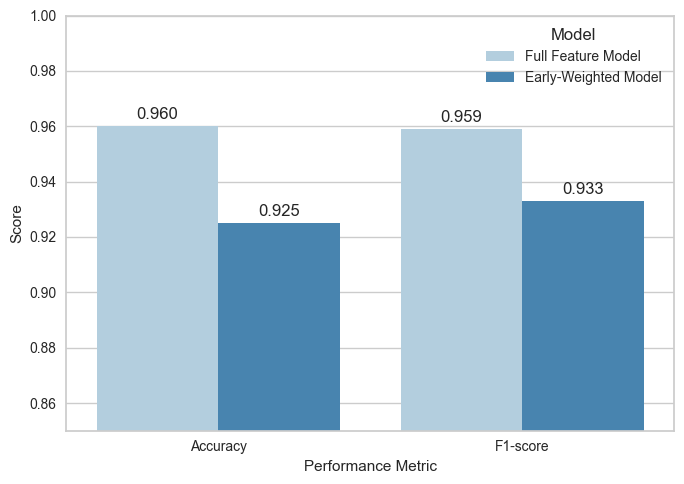

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Final comparison data
data = {
    'Metric': ['Accuracy', 'F1-score'],
    'Full Feature Model': [0.960, 0.959],
    'Early-Weighted Model': [0.925, 0.933]
}

df = pd.DataFrame(data)
df_melt = df.melt(id_vars='Metric', var_name='Model', value_name='Score')

plt.figure(figsize=(7,5))
sns.barplot(x='Metric', y='Score', hue='Model', data=df_melt, palette='Blues')

for container in plt.gca().containers:
    plt.bar_label(container, fmt='%.3f', padding=3)


plt.ylabel("Score")
plt.xlabel("Performance Metric")
plt.ylim(0.85, 1.0)
plt.tight_layout()
plt.show()


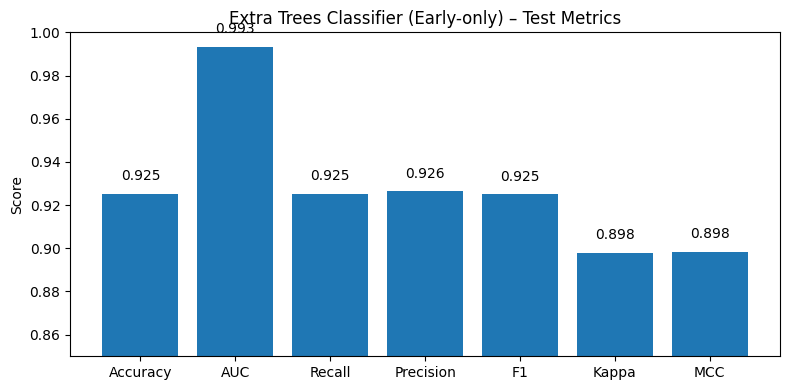

In [ ]:
import matplotlib.pyplot as plt

# Metrics and values from your table
metrics = ["Accuracy", "AUC", "Recall", "Precision", "F1", "Kappa", "MCC"]
values  = [0.9252, 0.9931, 0.9252, 0.9263, 0.9250, 0.8979, 0.8984]

plt.figure(figsize=(8, 4))
plt.bar(metrics, values,)
plt.ylim(0.85, 1.0)        # adjust if you want a different y-range

plt.ylabel("Score")
plt.title("Extra Trees Classifier (Early-only) – Test Metrics")

# Add value labels on top of each bar
for i, v in enumerate(values):
    plt.text(i, v + 0.005, f"{v:.3f}", ha="center", va="bottom")

plt.tight_layout()
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_11304\4076139054.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Metric', y='Mean', data=df_perf, palette='Blues_d')


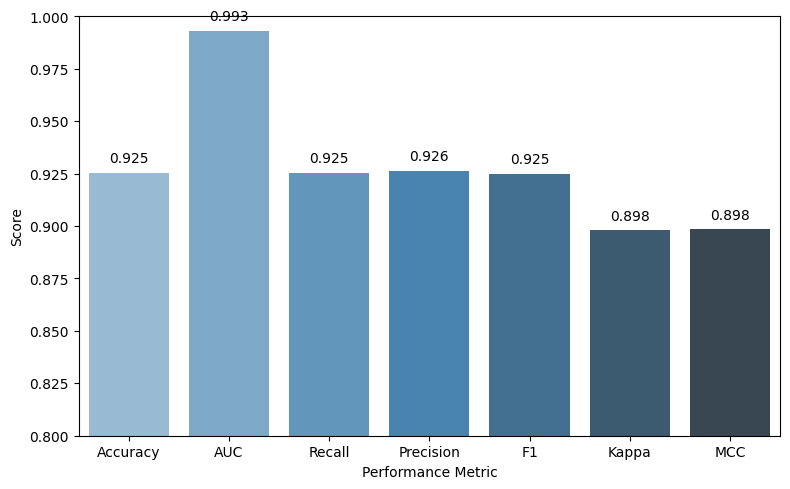

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Mean performance values from your table
data = {
    'Metric': ['Accuracy', 'AUC', 'Recall', 'Precision', 'F1', 'Kappa', 'MCC'],
    'Mean': [0.9252, 0.9931, 0.9252, 0.9263, 0.9250, 0.8979, 0.8984]}

# Convert to DataFrame
df_perf = pd.DataFrame(data)

# Plot bar chart
plt.figure(figsize=(8, 5))
sns.barplot(x='Metric', y='Mean', data=df_perf, palette='Blues_d')

# Add values on top of bars
for i, v in enumerate(df_perf['Mean']):
    plt.text(i, v + 0.005, f"{v:.3f}", ha='center', fontsize=10)

# Chart details

plt.ylim(0.8, 1.0)
plt.ylabel("Score")
plt.xlabel("Performance Metric")
plt.tight_layout()
plt.show()
